Aqui va todo de lo que estoy seguro de usar

In [35]:
from limpio import *
import numpy as np
from sklearn.preprocessing import RobustScaler
from keras.callbacks import EarlyStopping
import torch.nn as nn
import torch
import pandas as pd
from tradepy.features import create_targets, generate_features, data_quality_report
import pywt


In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

In [3]:
# for asset in asset_list:
#     df_min, spec = import_dataset(asset=asset)
#     df_min_clean = clean(df_min, asset=asset, break_hour=spec['break_start'])
#     plot_master_market_analysis(df_min_clean, asset_name=f"{asset}", tick_size=spec['tick_size'], show=False, save=True)

In [36]:
def wavelet_denoising(x, wavelet='db4', level=1):
    # Descomponer la señal
    coeffs = pywt.wavedec(x, wavelet, mode='per')
    # Aplicar umbral para eliminar ruido (detalles de alta frecuencia)
    sigma = (1/0.6745) * np.median(np.abs(coeffs[-level] - np.median(coeffs[-level])))
    uthresh = sigma * np.sqrt(2 * np.log(len(x)))
    coeffs[1:] = [pywt.threshold(i, value=uthresh, mode='hard') for i in coeffs[1:]]
    # Reconstruir
    return pywt.waverec(coeffs, wavelet, mode='per')

In [38]:
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, asset=ASSET, break_hour=spec['break_start'])
df_min_clean["close"] = wavelet_denoising(df_min_clean['close'].values.copy())
df_resampled = get_multitimeframe_data(df_min_clean)
# plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388
✅ Agregado: 5min | Filas: 901065
✅ Agregado: 15min | Filas: 300484
✅ Agregado: 30min | Filas: 153576
✅ Agregado: 60min | Filas: 76829


In [39]:
df_cumulative = apply_cumulative_stats_to_dict(df_resampled)

✅ Procesados acumulados diarios para: 5min
✅ Procesados acumulados diarios para: 15min
✅ Procesados acumulados diarios para: 30min
✅ Procesados acumulados diarios para: 60min


In [40]:
config = {
"global": {
"sampling_minutes": MINUTES,
"return_horizon_min": RETURN_HORIZON_MIN,
"tick_size": spec['tick_size']
},
"percent_return_features": {
"lags": [1,5,10,20],
"rolling_windows": [5,10,20]
},
"compute_atr": {"period": 14},
"obv": {
"roc_windows":[5,10],
"smooth_windows":[10],
"zscore_window":20,
"relative_volume_window":20,
"normalize_by":"range",
"include_manual": False,
"include_direction": True,
"include_delta": True
},
"ad": {
"zscore_window":20,
"roc_windows":[5,10],
"smooth_windows":[10],
"relative_volume_window":20,
"normalize_by":"range",
"include_clv": True,
"include_delta": True,
"include_direction": True
},
"rolling_slope": {"window":10, "source":"close"}
}

In [41]:
df_final = generate_features(df_cumulative[f'{MINUTES}min'], config_json=config, dropna_strategy='any')

In [78]:
report = data_quality_report(df_final, clean_infs=True, compute_corr=True, by_day=True)
print(report['column_profile'].sort_values('na_frac', ascending=False).head(30))

Data Quality Report
 - rows: 73437, cols: 144
 - top 20 NaN fractions:
datetime        0.0
open            0.0
high            0.0
low             0.0
close           0.0
volume          0.0
openint         0.0
dtyyyymmdd      0.0
ticker          0.0
per             0.0
trading_date    0.0
open_day        0.0
high_cum        0.0
low_cum         0.0
volume_cum      0.0
dist_to_high    0.0
dist_to_low     0.0
sma_20          0.0
ema_20          0.0
dema            0.0
dtype: float64
 - top corr with future: {'vpt': -0.02366713903005583, 'hour_cos': -0.01976680703240446, 'efi': -0.017778700677868717, 'ad_z': -0.01494703880438361, 'clv': -0.014799241621181982, 'close_location': -0.014799241556848662, 'ad_delta': -0.014053305179031148, 'bb_percent_b': -0.013603000235416393, 'cci': -0.012513157435633224, 'body_ticks': -0.012258020417762291, 'mfi': -0.012132451588802422, 'williams_r': -0.01199107920674621, 'dayofweek': -0.011600410625947234, 'slowd': -0.010992020712417517, 'slowk': -0.0109635

In [43]:
df_final_bin = create_targets(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], pos_threshold=0.0)

In [44]:
df_final_triple = create_targets(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], pos_threshold=0.000718 , ternary=True)

In [45]:
EXCLUDE_COLS_TRIPLE = [
    # Identificadores / metadata
    'datetime', 'dtyyyymmdd', 'ticker', 'per', 'trading_date',

    # Constantes por resampling
    # 'openint', 'minute', 'minute_sin', 'minute_cos',

    # Targets
    'target_logret_120m', 'target_ret_120m', 'target_ticks_120m',
    'target_bin', 'target_class',

    # Booleanos opcionales
    'is_month_end', 'is_doji'
]

FEATURE_COLS_TRIPLE = [col for col in df_final_triple.columns if col not in EXCLUDE_COLS_TRIPLE]

EXCLUDE_COLS_BIN = [
    # Identificadores / metadata
    'datetime', 'dtyyyymmdd', 'ticker', 'per', 'trading_date',

    # Constantes por resampling
    # 'openint', 'minute', 'minute_sin', 'minute_cos',

    # Targets
    'target_logret_120m', 'target_ret_120m', 'target_ticks_120m',
    'target_bin',

    # Booleanos opcionales
    'is_month_end', 'is_doji'
]

FEATURE_COLS_BIN = [col for col in df_final_bin.columns if col not in EXCLUDE_COLS_BIN]

In [46]:
df_final_bin = audit_single_df(df_final_bin, FEATURE_COLS_BIN + ['target_bin'])
df_final_triple = audit_single_df(df_final_triple, FEATURE_COLS_TRIPLE + ['target_class'])

💎 Sin NaNs en features
💎 Sin NaNs en features


In [47]:
# df_final_dict = process_full_dictionary(df_cumulative, spec)

In [48]:
# df_final_dict[f'{MINUTES}min'].iloc[0].to_dict()

In [49]:
TARGET_COLUMN_BIN = 'target_bin' # 1 si sube, 0 si baja/lateral
TARGET_COLUMN_TRIPLE = 'target_class' # 2 si sube, 1 si lateral, 0 si baja

In [50]:
# df_final_dict = audit_and_clean_dict(df_final_dict, FEATURE_COLUMNS)

In [51]:
result_bin, model_bin, sc_bin = run_gold_master_workflow(df_final_bin, FEATURE_COLS_BIN, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_BIN, train_size=20000, test_size=1000, step=500, lookback=48)

🤖 Auto-seleccionado: Binario Model


Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

In [52]:
result_triple, model_triple, sc_triple = run_gold_master_workflow(df_final_triple, FEATURE_COLS_TRIPLE, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48)

🤖 Auto-seleccionado: Triple Model


Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_gold_performance(full_results):
    """
    Analiza estadísticamente los resultados del Walk-Forward.
    """
    y_true = full_results['actual']
    y_pred = full_results['pred']
    
    # 1. Identificar etiquetas
    unique_labels = sorted(full_results['actual'].unique())
    if len(unique_labels) == 2:
        target_names = ['No Sube (0)', 'Sube (1)']
    else:
        target_names = ['Sell (0)', 'Neutral (1)', 'Buy (2)']

    # 2. Generar Reporte de Clasificación
    print("📊 --- REPORTE DE CLASIFICACIÓN ---")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 3. Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicción (Modelo)')
    plt.ylabel('Realidad (Mercado)')
    plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?')
    plt.show()

    # 4. Análisis de "Edge" (Ventaja Estadística)
    # Calculamos el retorno promedio por cada tipo de predicción
    print("\n💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---")
    edge_analysis = full_results.groupby('pred')['ret_real'].mean()
    for label, avg_ret in edge_analysis.items():
        name = target_names[int(label)]
        print(f"Cuando el modelo predice {name}, el retorno promedio real es: {avg_ret:.6f}")
    
    return accuracy_score(y_true, y_pred)

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 No Sube (0)       0.51      0.53      0.52     49876
    Sube (1)       0.51      0.49      0.50     50084

    accuracy                           0.51     99960
   macro avg       0.51      0.51      0.51     99960
weighted avg       0.51      0.51      0.51     99960



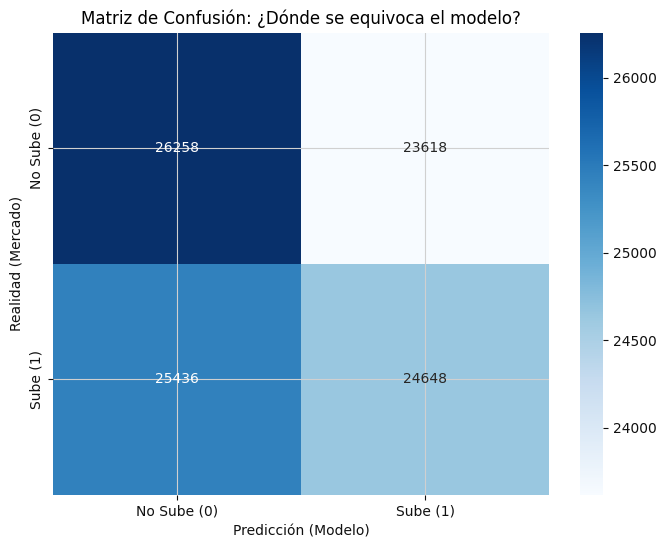


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice No Sube (0), el retorno promedio real es: -0.000014
Cuando el modelo predice Sube (1), el retorno promedio real es: 0.000057


0.5092637054821929

In [54]:
evaluate_gold_performance(result_bin)

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Sell (0)       0.33      0.49      0.40     32373
 Neutral (1)       0.49      0.11      0.17     34776
     Buy (2)       0.35      0.47      0.40     32811

    accuracy                           0.35     99960
   macro avg       0.39      0.36      0.32     99960
weighted avg       0.39      0.35      0.32     99960



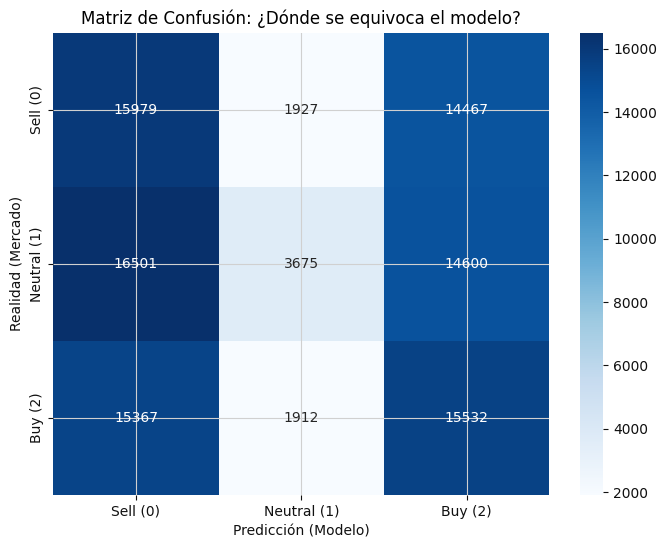


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice Sell (0), el retorno promedio real es: -0.000010
Cuando el modelo predice Neutral (1), el retorno promedio real es: 0.000020
Cuando el modelo predice Buy (2), el retorno promedio real es: 0.000054


0.35200080032012804

In [55]:
evaluate_gold_performance(result_triple)

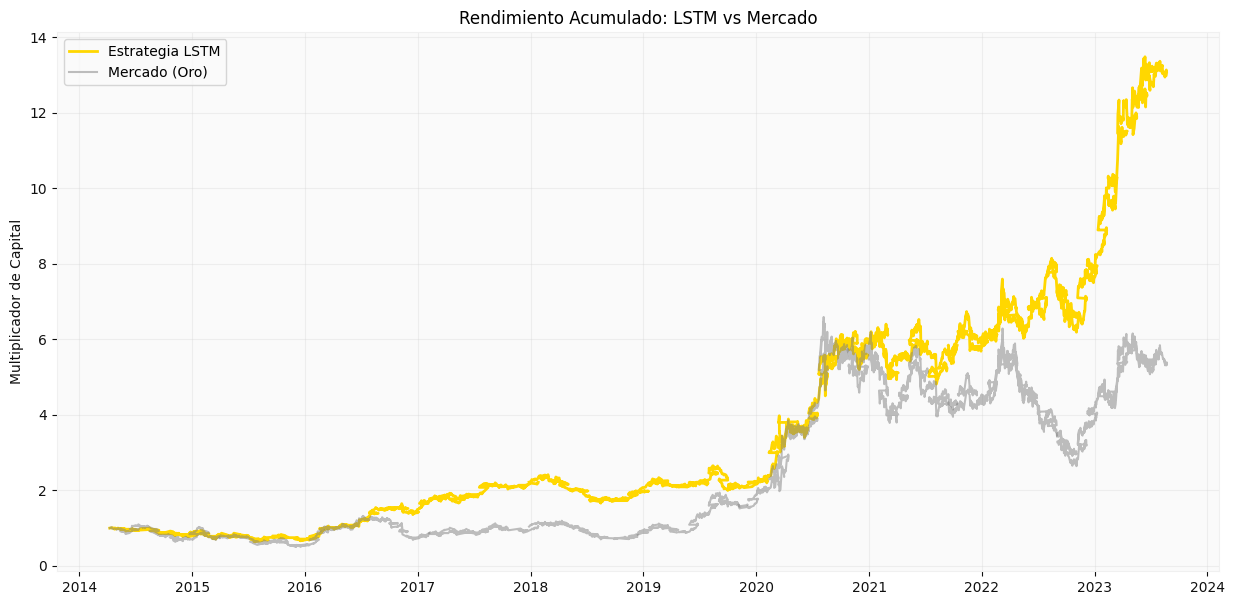

💰 Sharpe Ratio Estimado: 0.23
📈 Retorno Total Estrategia: 1208.55%


In [56]:
plot_trading_results(result_bin)

In [63]:
import xgboost as xgb
import shap
def get_top_features_shap(df, target_col, feature_cols, top_n=25):

    # 1. Limpieza de NaNs
    df_clean = df[feature_cols + [target_col]].dropna()
    X = df_clean[feature_cols]
    y = df_clean[target_col]
    
    # 2. Entrenamiento rápido
    model = xgb.XGBClassifier(n_estimators=100, max_depth=4, tree_method='hist')
    model.fit(X, y)

    # 3. Cálculo de SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # --- BLOQUE DE CORRECCIÓN DE DIMENSIONES ---
    # SHAP multiclase devuelve (muestras, features, clases) o una lista de arrays
    if isinstance(shap_values, list):
        # Caso: Lista de arrays (uno por clase)
        abs_val = np.abs(np.array(shap_values)).mean(axis=0) # Promedio entre clases
        mean_shap = abs_val.mean(axis=0) # Promedio entre muestras
    elif len(shap_values.shape) == 3:
        # Caso: Array 3D (muestras, features, clases)
        mean_shap = np.abs(shap_values).mean(axis=(0, 2))
    else:
        # Caso: Binario (muestras, features)
        mean_shap = np.abs(shap_values).mean(axis=0)
    
    # Verificación de seguridad
    if len(mean_shap) != len(feature_cols):
        print(f"⚠️ Error de dimensión: SHAP {len(mean_shap)} vs Cols {len(feature_cols)}")
        # Forzar ajuste si algo sale mal (fallback)
        mean_shap = mean_shap[:len(feature_cols)]

    # 4. Crear DataFrame de resultados
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': mean_shap
    }).sort_values(by='importance', ascending=False)

    # 5. Top N y Gráfico
    top_features = importance_df.head(top_n)['feature'].tolist()
    
    plt.figure(figsize=(10, 8))
    # Usamos el resumen de barras nativo de SHAP para el top_n
    shap.summary_plot(shap_values, X, plot_type="bar", max_display=top_n, show=True)
    
    return top_features, importance_df

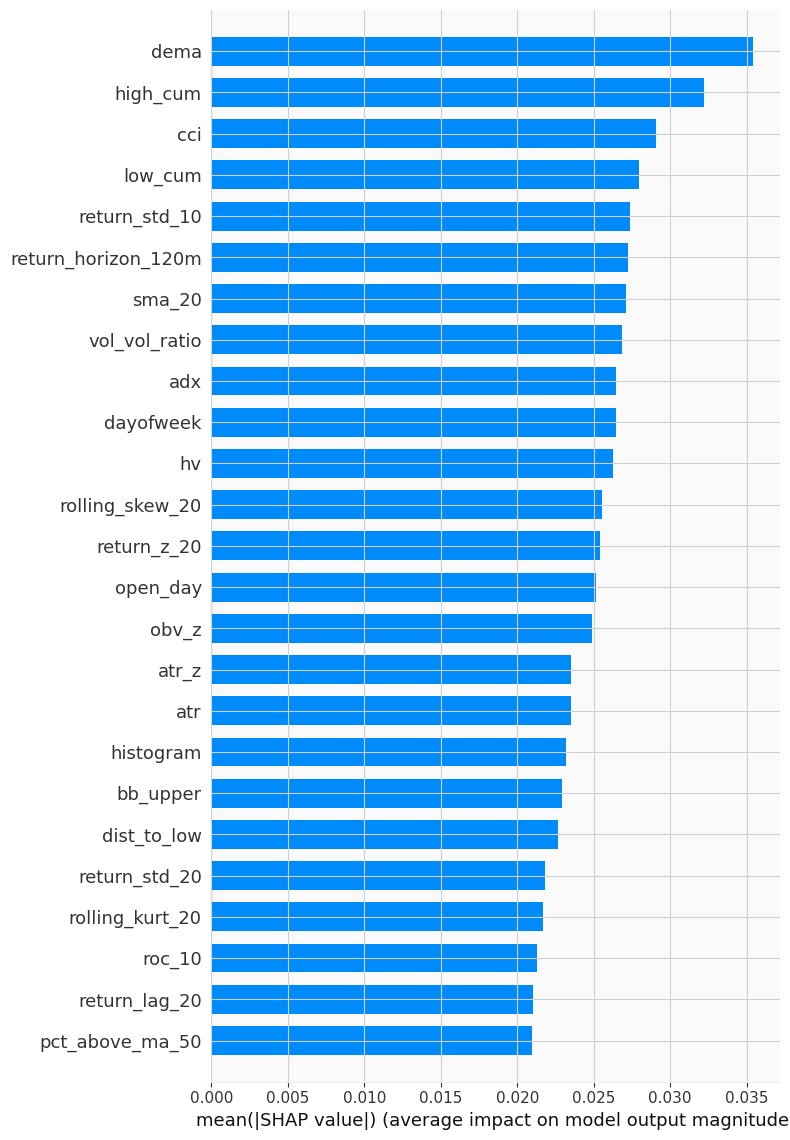

In [66]:
top_features_bin, importance_df_bin = get_top_features_shap(df_final_bin, TARGET_COLUMN_BIN, FEATURE_COLS_BIN, top_n=25)


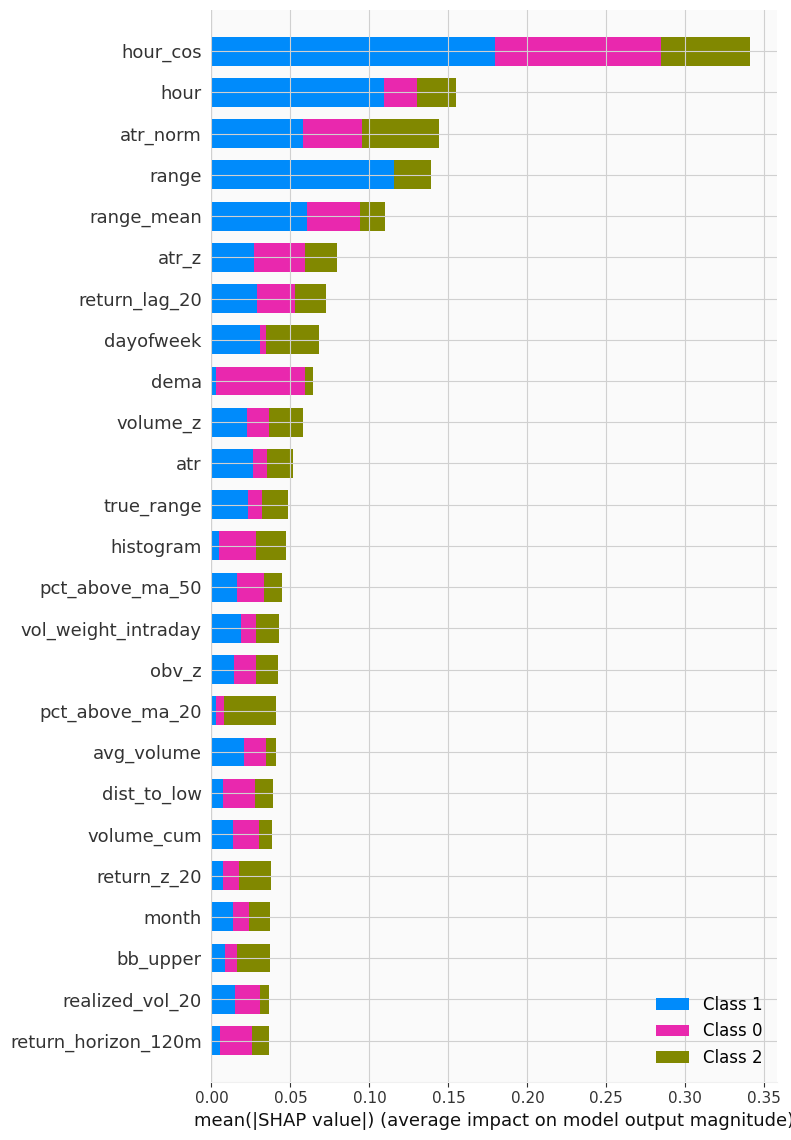

In [67]:
top_features_triple, importance_df_triple = get_top_features_shap(df_final_triple, TARGET_COLUMN_TRIPLE, FEATURE_COLS_TRIPLE, top_n=25)


In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def reduce_by_vif(df, feature_list, threshold=10.0):
    """
    Calcula el VIF y elimina features una a una hasta que todas 
    estén por debajo del umbral (threshold).
    """
    # 1. Copiamos y limpiamos NaNs (VIF no acepta NaNs)
    X = df[feature_list].dropna().copy()
    # Añadimos una constante (requerido por statsmodels para el cálculo)
    X = add_constant(X)
    
    current_features = list(X.columns)
    
    while True:
        vif_data = pd.DataFrame()
        vif_data["feature"] = current_features
        vif_data["VIF"] = [variance_inflation_factor(X[current_features].values, i) 
                           for i in range(len(current_features))]
        
        # Ignoramos la constante para la eliminación
        vif_filtered = vif_data[vif_data["feature"] != "const"]
        max_vif = vif_filtered["VIF"].max()
        
        if max_vif > threshold:
            feature_to_remove = vif_filtered.sort_values("VIF", ascending=False).iloc[0]["feature"]
            print(f"🗑️ Eliminando '{feature_to_remove}' (VIF: {max_vif:.2f})")
            current_features.remove(feature_to_remove)
        else:
            break
            
    final_features = [f for f in current_features if f != "const"]
    print(f"✅ Proceso terminado. Quedan {len(final_features)} features independientes.")
    return final_features

# --- USO ---
# features_finales = reduce_by_vif(df_final, top_25_shap, threshold=10.0)

In [71]:
features_finales_bin =reduce_by_vif(df_final_bin, top_features_bin, threshold=10.0)

🗑️ Eliminando 'low_cum' (VIF: 107462.92)
🗑️ Eliminando 'hv' (VIF: 44027.39)
🗑️ Eliminando 'sma_20' (VIF: 39623.16)
🗑️ Eliminando 'high_cum' (VIF: 8301.45)
🗑️ Eliminando 'dema' (VIF: 6145.41)
🗑️ Eliminando 'bb_upper' (VIF: 2047.33)
✅ Proceso terminado. Quedan 19 features independientes.


In [72]:
final_features_triple = reduce_by_vif(df_final_triple, top_features_triple, threshold=10.0)

🗑️ Eliminando 'true_range' (VIF: 23807.51)
🗑️ Eliminando 'bb_upper' (VIF: 4182.74)
🗑️ Eliminando 'atr' (VIF: 61.33)
🗑️ Eliminando 'pct_above_ma_20' (VIF: 54.81)
🗑️ Eliminando 'range_mean' (VIF: 10.21)
✅ Proceso terminado. Quedan 20 features independientes.


In [73]:
result_bin_second, model_bin_second, sc_bin_second = run_gold_master_workflow(df_final_bin, features_finales_bin, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_BIN, train_size=20000, test_size=1000, step=500, lookback=48)

🤖 Auto-seleccionado: Binario Model


Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 No Sube (0)       0.50      0.51      0.51     49876
    Sube (1)       0.51      0.50      0.50     50084

    accuracy                           0.51     99960
   macro avg       0.51      0.51      0.51     99960
weighted avg       0.51      0.51      0.51     99960



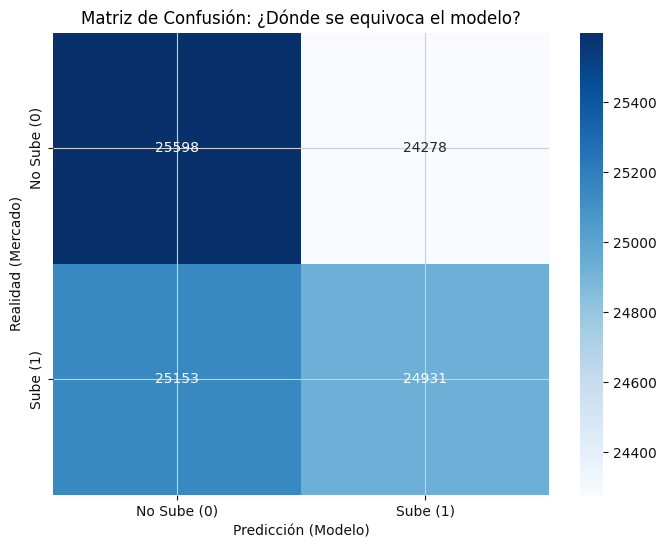


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice No Sube (0), el retorno promedio real es: 0.000012
Cuando el modelo predice Sube (1), el retorno promedio real es: 0.000030


0.5054921968787515

In [74]:
evaluate_gold_performance(result_bin_second)

In [75]:
result_triple_second, model_triple_second, sc_triple_second = run_gold_master_workflow(df_final_triple, final_features_triple, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48)

🤖 Auto-seleccionado: Triple Model


Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Sell (0)       0.33      0.50      0.40     32373
 Neutral (1)       0.61      0.07      0.12     34776
     Buy (2)       0.34      0.50      0.41     32811

    accuracy                           0.35     99960
   macro avg       0.43      0.36      0.31     99960
weighted avg       0.43      0.35      0.30     99960



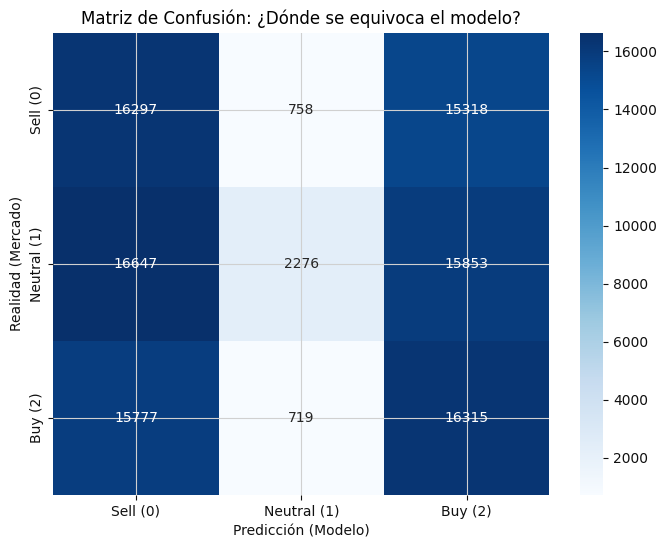


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice Sell (0), el retorno promedio real es: -0.000013
Cuando el modelo predice Neutral (1), el retorno promedio real es: -0.000011
Cuando el modelo predice Buy (2), el retorno promedio real es: 0.000057


0.34901960784313724

In [76]:
evaluate_gold_performance(result_triple_second)

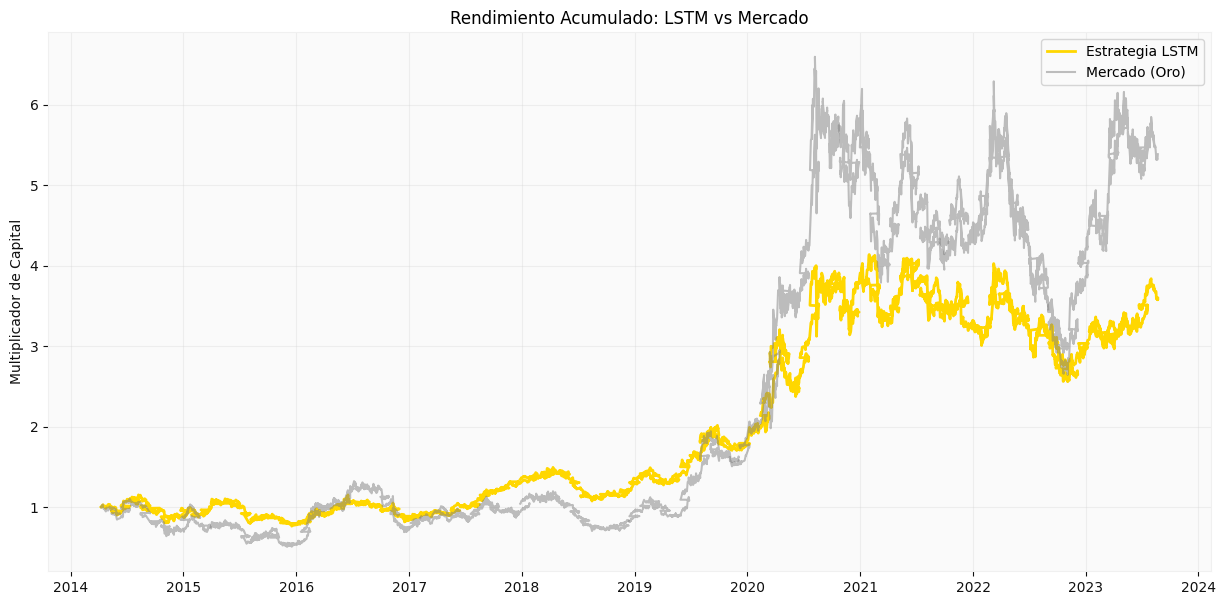

💰 Sharpe Ratio Estimado: 0.12
📈 Retorno Total Estrategia: 259.32%


In [77]:
plot_trading_results(result_bin_second)

In [11]:
# Calculamos la volatilidad media (ATR simplificado) para que el umbral sea lógico
volatilidad_media = df_final_dict[f'{MINUTES}min']['target_ret_30m'].abs().mean()
print(f"Volatilidad media cada 30 min: {volatilidad_media:.5f}")

# Umbral: Solo queremos operar si el movimiento esperado es mayor que la media
threshold = volatilidad_media * 0.7

Volatilidad media cada 30 min: 0.00222


In [12]:
# Definir el umbral (ajustar según volatilidad)
# threshold = 0.0005 

def label_triple(ret):
    if ret > threshold:
        return 2 # Buy
    elif ret < -threshold:
        return 0 # Sell
    else:
        return 1 # Neutral

df_final_dict[f'{MINUTES}min']['target_triple'] = df_final_dict[f'{MINUTES}min']['target_ret_30m'].apply(label_triple)

# Verifica el balance de clases
print(df_final_dict[f'{MINUTES}min']['target_triple'].value_counts(normalize=True))

target_triple
1    0.532873
2    0.237340
0    0.229787
Name: proportion, dtype: float64


In [13]:
class GoldLSTM_Triple(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(GoldLSTM_Triple, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout)
        
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 3) # Salida para: [Sell, Neutral, Buy]

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] 
        
        out = self.batch_norm(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out) # Retorna logits

In [14]:
class GoldLSTM_V2(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2): # Más ligero
        super(GoldLSTM_V2, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 3) # Directo a las 3 clases

    def forward(self, x):
        # Usamos solo el último estado oculto
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        return self.fc(out)

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Definir Pesos de Clase (Penalizamos más el fallo en Buy/Sell)
# Clase 0 (Sell): Peso 2.5 | Clase 1 (Neutral): Peso 1.0 | Clase 2 (Buy): Peso 2.5
class_weights = torch.tensor([2.5, 1.0, 2.5], dtype=torch.float32).to("cuda")

def run_walk_forward_triple_final(df, feature_cols, target_col='target_triple'):
    device = torch.device("cuda")
    scaler_amp = torch.amp.GradScaler('cuda')
    all_predictions = []
    
    # Parámetros óptimos para tu 3060
    # train_size=5000, test_size=1000, step=500, lookback=24
    train_size, test_size, step = 5000, 1000, 500
    lookback, epochs, batch_size = 24, 10, 512 # Subimos epochs y batch_size
    
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    
    for start in tqdm(range(0, len(df_wf) - train_size - test_size, step), desc="Training Triple"):
        # ... [Segmentación y Escalado RobustScaler igual que antes] ...
        end_train = start + train_size
        end_test = end_train + test_size
        
        # --- Preprocesado y Escalado ---
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])
        
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Preparar Tensores
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device) # LONG para CrossEntropy
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        # Modelo
        model = GoldLSTM_Triple(input_dim=len(feature_cols)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        criterion = nn.CrossEntropyLoss(weight=class_weights) # <--- PESOS AQUÍ
        
        # Entrenamiento con AMP
        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
        
        # Predicción
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            
        # ... [Guardar en DataFrame res_df como el anterior] ...
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': preds,
            'prob_sell': probs[:, 0],
            'prob_neutral': probs[:, 1],
            'prob_buy': probs[:, 2],
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        all_predictions.append(res_df)
        torch.cuda.empty_cache()
        print(f"✅ Ventana {df_wf['datetime'].iloc[start].date()} OK. Acc: {(preds == y_test).mean():.2%}")

    return pd.concat(all_predictions, ignore_index=True)

In [16]:
result_triple = run_walk_forward_triple_final(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS)

Training Triple:   0%|          | 0/137 [00:00<?, ?it/s]

✅ Ventana 2010-09-21 OK. Acc: 40.47%
✅ Ventana 2010-10-20 OK. Acc: 41.70%
✅ Ventana 2010-11-18 OK. Acc: 38.83%
✅ Ventana 2010-12-17 OK. Acc: 37.81%
✅ Ventana 2011-01-18 OK. Acc: 35.35%
✅ Ventana 2011-02-16 OK. Acc: 35.35%
✅ Ventana 2011-03-17 OK. Acc: 40.37%
✅ Ventana 2011-04-15 OK. Acc: 38.93%
✅ Ventana 2011-05-17 OK. Acc: 43.55%
✅ Ventana 2011-06-15 OK. Acc: 40.68%
✅ Ventana 2011-07-15 OK. Acc: 39.45%
✅ Ventana 2011-08-15 OK. Acc: 42.11%
✅ Ventana 2011-09-13 OK. Acc: 48.16%
✅ Ventana 2011-10-12 OK. Acc: 45.39%
✅ Ventana 2011-11-10 OK. Acc: 42.73%
✅ Ventana 2011-12-09 OK. Acc: 44.88%
✅ Ventana 2012-01-11 OK. Acc: 48.98%
✅ Ventana 2012-02-09 OK. Acc: 51.23%
✅ Ventana 2012-03-12 OK. Acc: 50.51%
✅ Ventana 2012-04-11 OK. Acc: 54.61%
✅ Ventana 2012-05-10 OK. Acc: 50.20%
✅ Ventana 2012-06-08 OK. Acc: 42.83%
✅ Ventana 2012-07-09 OK. Acc: 44.67%
✅ Ventana 2012-08-07 OK. Acc: 38.32%
✅ Ventana 2012-09-05 OK. Acc: 36.27%
✅ Ventana 2012-10-04 OK. Acc: 36.78%
✅ Ventana 2012-11-02 OK. Acc: 38.32%
✅

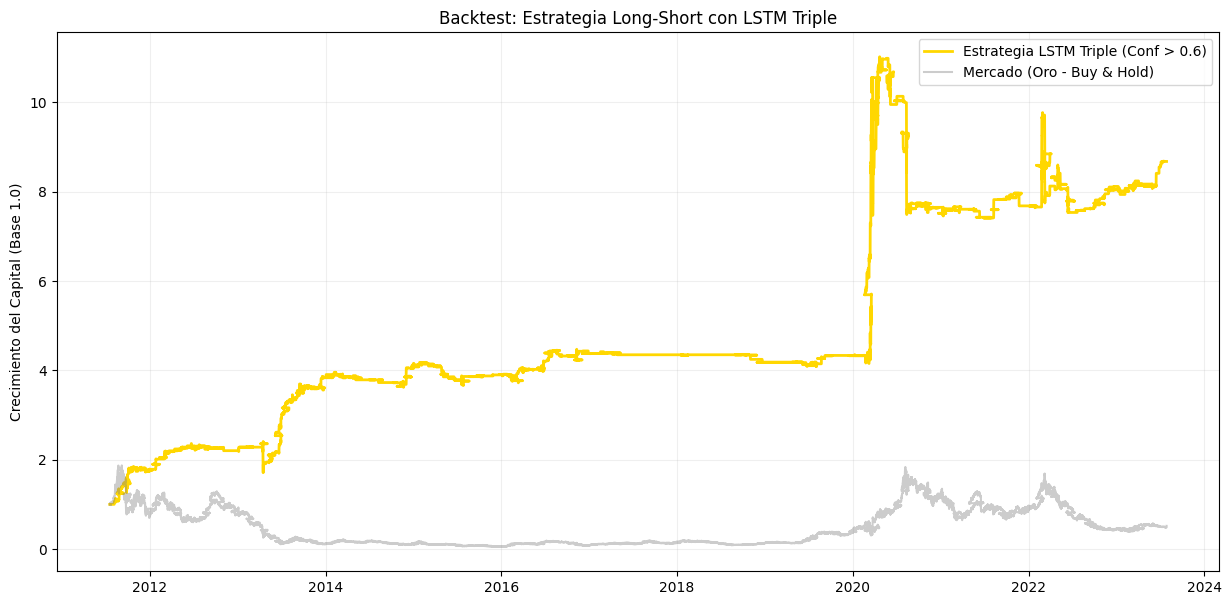

------------------------------
💰 NUEVO Sharpe Ratio: 1.61
📈 Retorno Total: 767.46%
🎯 Win Rate (de los trades): 55.68%
📊 Ratio de Operatividad: 2.92% (tiempo en mercado)
📉 Total de Trades: 3906 de 133712 velas
------------------------------


In [17]:
plot_triple_trading_results(result_triple, 0.6)

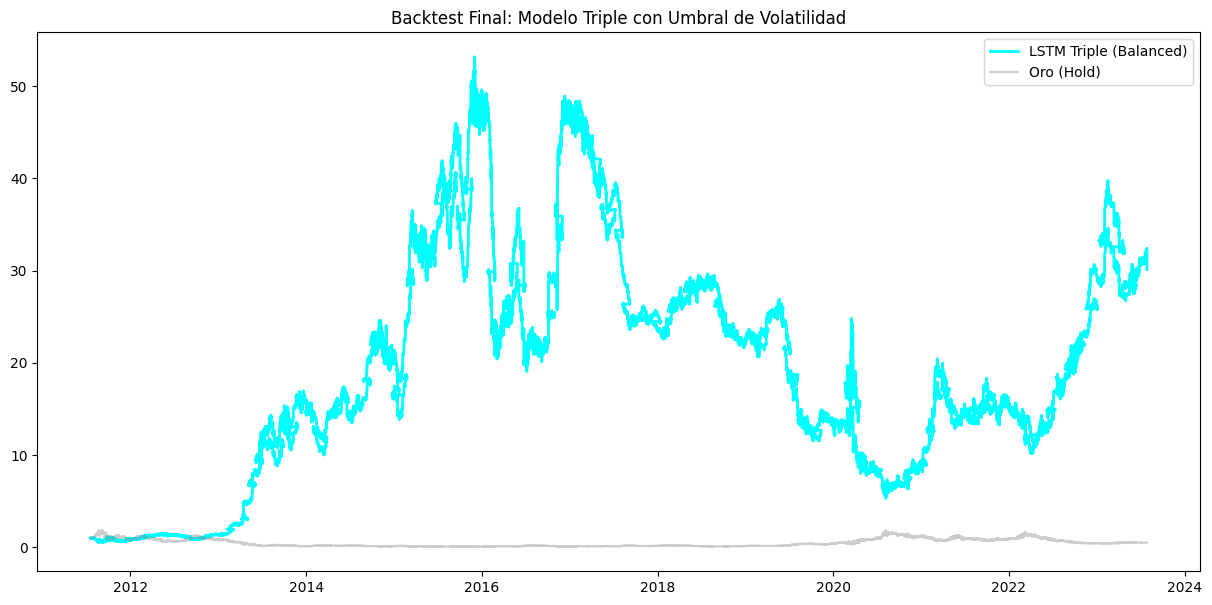

💰 Sharpe Ratio Esperado: 1.04


In [18]:
plot_triple_final_comparison(result_triple)

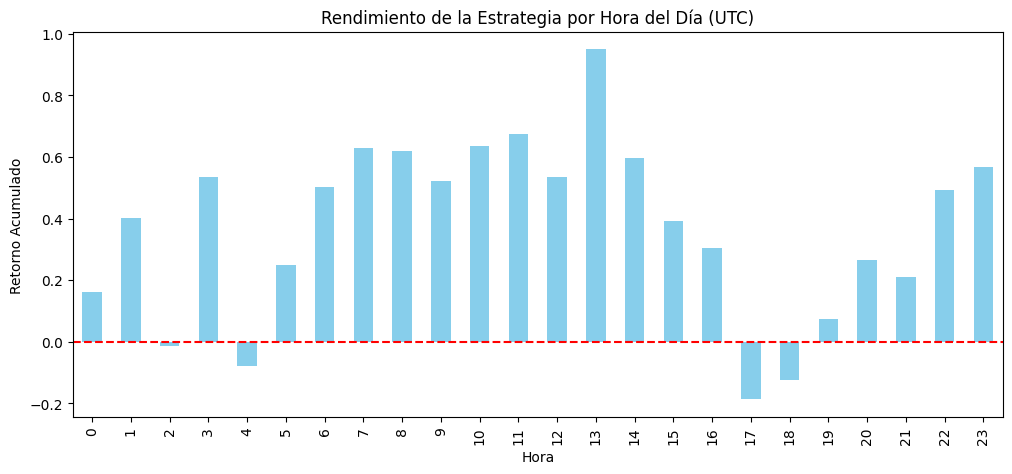

In [19]:
analyze_by_hour(result_triple)

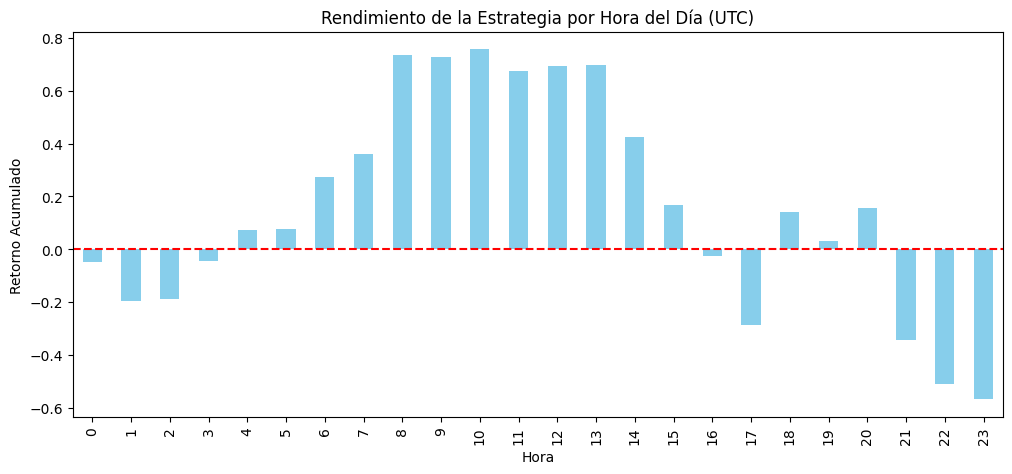

In [20]:
analyze_by_hour(result_torch)

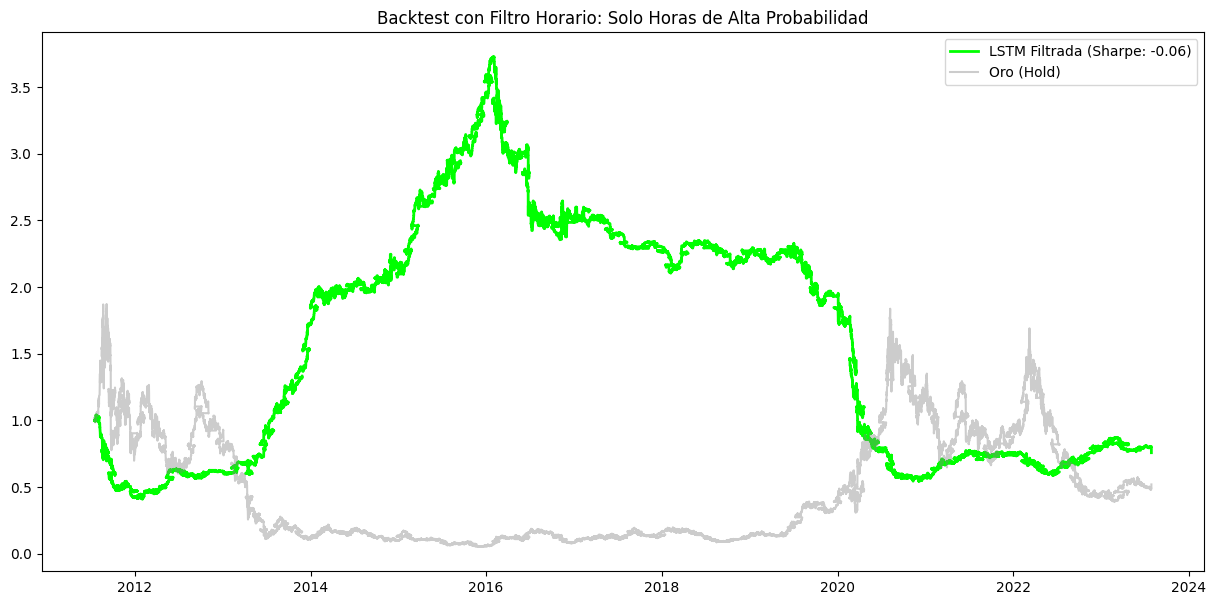

🚀 Sharpe Ratio con Filtro: -0.06


In [21]:
plot_backtest_filtrado(result_triple)

In [22]:
print(f"📊 El Sharpe Ratio REAL de este modelo es: {calculate_real_sharpe_binary(result_torch):.4f}")

✅ Análisis del Modelo Binario:
-------------------------------
💰 Retorno Acumulado Estrategia: 33.8851
📈 Retorno Acumulado Mercado:    0.5192
📊 El Sharpe Ratio REAL de este modelo es: 1.2874


In [23]:
calculate_sharpe_triple(result_triple)

📈 Resultado Final:
-------------------
💰 Sharpe Ratio: 2.2582
🚀 Retorno Total: 367864.39%
⚖️ Operaciones totales: 82899 de 133712


np.float64(2.2581588691014574)

In [24]:
calculate_final_binary_sharpe(result_torch)

📊 --- RESULTADOS BINARIOS ---
💰 Sharpe Ratio: 1.2874
📉 Volatilidad Anual: 27.75%
📈 Retorno Final: 33.8851
-------------------------------


np.float64(1.2873641565878773)

In [25]:
result_torch_filtered = apply_time_filter(result_torch) # Usa el df que tiene prob_up


🚀 Sharpe Original: 0.6245
💎 Sharpe Filtrado: 0.9247


In [26]:
stress_test_with_costs(result_torch_filtered, 0.0002)


🧪 --- STRESS TEST (1 TICK COST) ---
📉 Sharpe con Costes: -0.0024
💰 Retorno Final tras costes: 0.8032
🚪 Total de entradas pagadas: 10080
------------------------------------


np.float64(-0.0024124267457365195)

In [27]:
# Sobre el dataframe original de 3028 operaciones
avg_ret_per_trade = result_torch_filtered[result_torch_filtered['signal_final'] == 1]['ret_real'].mean()
print(f"Retorno medio por trade: {avg_ret_per_trade:.6f}")

Retorno medio por trade: 0.000053


In [ ]:
close_map = df_final_dict[f'{MINUTES}min'].set_index('datetime')['close']
result_torch_filtered['close'] = result_torch_filtered['datetime'].map(close_map)

In [33]:
result_triple['close'] = result_triple['datetime'].map(close_map)

In [29]:
run_backtest_pro(result_torch_filtered, tp_ticks=8, sl_ticks=4)

🏆 Resultado con Gestión de Riesgo (TP:8 / SL:4 ticks):
📊 Sharpe Neto: 7.8178
💰 Retorno Total: 7.4150


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002130,1.002130,1.002130,1,4,1,0.002130,1594.5,0.000439
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001754,1.003888,1.003888,1,5,1,0.001754,1594.6,0.000439
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001628,1.005522,1.005522,1,6,1,0.001628,1595.8,0.000439
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000876,1.006403,1.006403,1,7,1,0.000876,1597.9,0.000438
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001564,1.007977,1.007977,1,8,1,0.001564,1597.4,0.000438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000817,31.993982,0.490243,1,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000460,31.979280,0.490018,1,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020065,32.620940,0.499850,1,21,1,0.020065,1958.8,0.000357
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018964,33.239576,0.509329,1,22,0,0.000000,1958.7,0.000000


In [30]:
run_backtest_managed_with_costs(result_torch_filtered, tp_ticks=40, sl_ticks=20, cost_in_ticks=2, tick_val=0.0001)

✅ TP: 40 | SL: 20 | Coste: 2 ticks
📊 Sharpe Neto Final: 15.9759
💰 Retorno Acumulado: 1.0225


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002130,1.002130,1.002130,1,4,1,0.002130,1594.5,0.000002
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001754,1.003888,1.003888,1,5,1,0.001754,1594.6,0.000002
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001628,1.005522,1.005522,1,6,1,0.001628,1595.8,0.000002
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000876,1.006403,1.006403,1,7,1,0.000876,1597.9,0.000002
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001564,1.007977,1.007977,1,8,1,0.001564,1597.4,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000817,31.993982,0.490243,1,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000460,31.979280,0.490018,1,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020065,32.620940,0.499850,1,21,1,0.020065,1958.8,0.000002
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018964,33.239576,0.509329,1,22,0,0.000000,1958.7,0.000000


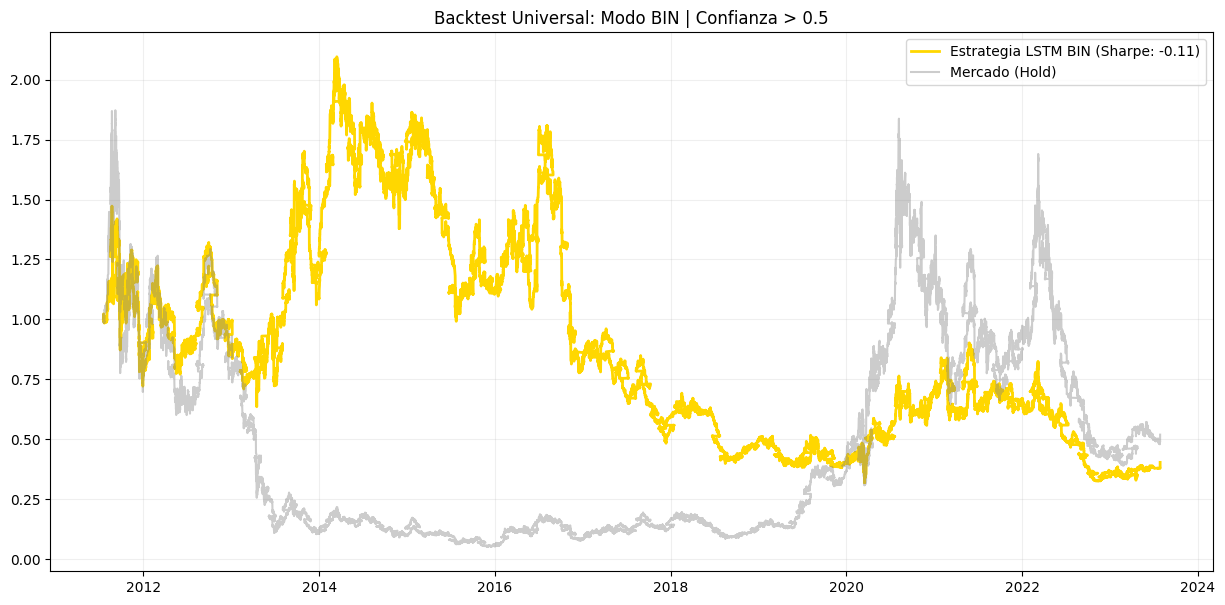

✅ Modo detectado: BIN
💰 Sharpe Ratio: -0.11
🎯 Win Rate: 49.07%


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002067,1.002067,1.002130,1,4,1,0.002130,1594.5
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001692,1.003763,1.003888,1,5,1,0.001754,1594.6
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001565,1.005334,1.005522,1,6,1,0.001628,1595.8
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000813,1.006151,1.006403,1,7,1,0.000876,1597.9
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001501,1.007662,1.007977,1,8,1,0.001564,1597.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000868,0.381225,0.490243,1,19,0,-0.000000,1960.3
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000511,0.381030,0.490018,1,20,0,-0.000000,1959.0
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020014,0.388656,0.499850,1,21,1,0.020065,1958.8
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018913,0.396007,0.509329,1,22,0,0.000000,1958.7


In [31]:
plot_universal_backtest(result_torch_filtered)

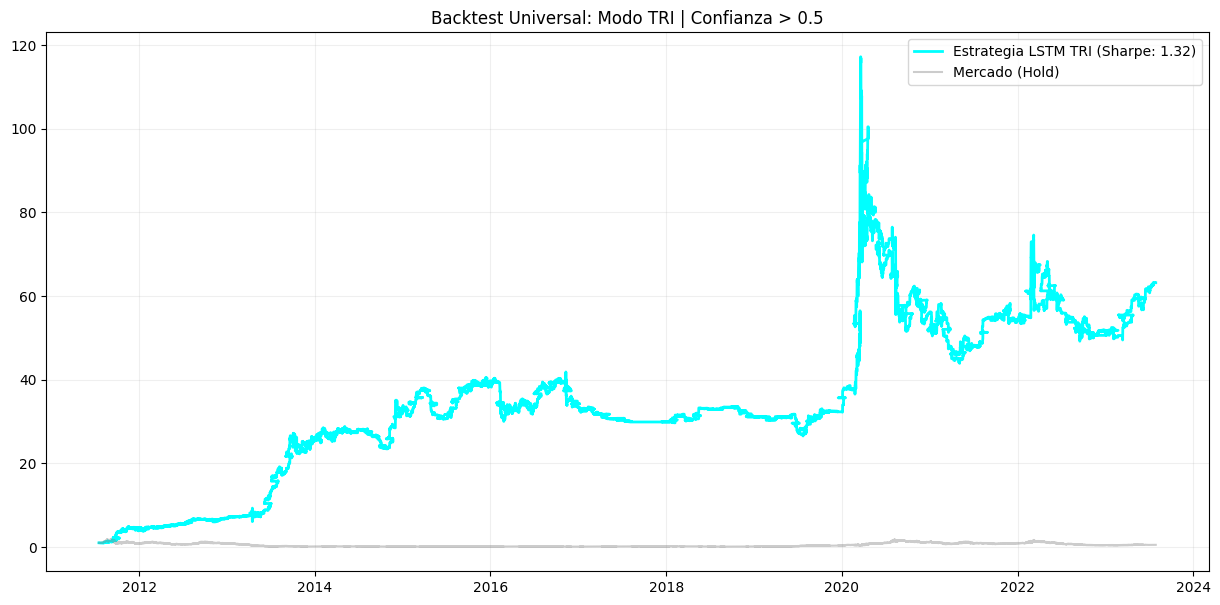

✅ Modo detectado: TRI
💰 Sharpe Ratio: 1.32
🎯 Win Rate: 52.66%


,datetime,actual,pred,prob_sell,prob_neutral,prob_buy,ret_real,close,signal,strat_ret,cum_strat,cum_market
0,2011-07-18 04:00:00,2,1,0.243226,0.460301,0.296473,0.002130,1594.5,0,0.0,1.000000,1.002130
1,2011-07-18 05:00:00,2,1,0.240879,0.445072,0.314049,0.001754,1594.6,0,0.0,1.000000,1.003888
2,2011-07-18 06:00:00,2,1,0.272804,0.404358,0.322838,0.001628,1595.8,0,0.0,1.000000,1.005522
3,2011-07-18 07:00:00,1,1,0.294130,0.384617,0.321253,0.000876,1597.9,0,0.0,1.000000,1.006403
4,2011-07-18 08:00:00,2,1,0.310271,0.367410,0.322320,0.001564,1597.4,0,0.0,1.000000,1.007977
...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,1,2,0.388232,0.195632,0.416136,-0.000817,1960.3,0,-0.0,63.205513,0.490243
133708,2023-07-28 20:00:00,1,2,0.362487,0.202768,0.434746,-0.000460,1959.0,0,-0.0,63.205513,0.490018
133709,2023-07-28 21:00:00,2,2,0.333048,0.212014,0.454938,0.020065,1958.8,0,0.0,63.205513,0.499850
133710,2023-07-28 22:00:00,2,2,0.295610,0.219352,0.485038,0.018964,1958.7,0,0.0,63.205513,0.509329


In [34]:
plot_universal_backtest(result_triple)

In [31]:
import shap

def run_shap_analysis(model, train_loader, test_loader, feature_names):
    # 1. Preparar una muestra de datos (SHAP necesita tensores de fondo)
    # Tomamos el primer batch del train_loader como "background"
    batch_train_x, _ = next(iter(train_loader))
    batch_test_x, _ = next(iter(test_loader))
    
    # SHAP en PyTorch prefiere trabajar con tensores en CPU para la explicación
    model.cpu()
    background = batch_train_x[:100].cpu() # 100 ejemplos de fondo son suficientes
    test_samples = batch_test_x[:20].cpu()   # Explicamos las primeras 20 predicciones
    
    # 2. Inicializar el Explainer
    # DeepExplainer es ideal para redes neuronales
    explainer = shap.DeepExplainer(model, background)
    
    # 3. Calcular valores SHAP
    shap_values = explainer.shap_values(test_samples)
    
    # 4. Visualización
    print("📊 Generando Summary Plot...")
    # Como los datos son [batch, window, features], colapsamos el tiempo 
    # para ver la importancia general de la feature
    shap_values_collapsed = np.mean(np.abs(shap_values), axis=1) 
    
    shap.summary_plot(
        shap_values_collapsed, 
        features=test_samples.mean(dim=1).numpy(), 
        feature_names=feature_names,
        plot_type="bar"
    )

# Uso:
# run_shap_analysis(model_torch, train_loader, test_loader, feature_cols)

In [32]:
def explain_gold_model(model, df_test, feature_cols, lookback, scaler):
    # 1. Mover modelo a CPU y poner en modo entrenamiento (necesario para SHAP)
    model.cpu()
    model.train() 
    
    # Desactivamos capas que cambian el comportamiento en train
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.BatchNorm1d)):
            module.eval()

    # 2. Preparación de datos (Directo en CPU)
    df_test_scaled = df_test.copy()
    df_test_scaled[feature_cols] = scaler.transform(df_test_scaled[feature_cols])
    
    X_test_shap, _ = create_lstm_dataset(df_test_scaled, feature_cols, target_col='target_bin', lookback=lookback)
    
    # Aseguramos tensores en CPU y Float32
    X_tensor = torch.tensor(X_test_shap, dtype=torch.float32).cpu()
    
    # 3. Muestras para el análisis
    # Usar 50 de fondo y 20 para explicar es suficiente para ver la tendencia
    background = X_tensor[:50] 
    test_samples = X_tensor[50:70] 
    
    # 4. Explicador SHAP
    # DeepExplainer funciona bien con LSTMs en CPU
    explainer = shap.DeepExplainer(model, background)
    
    # # 5. Cálculo de valores SHAP
    # print("⏳ Calculando valores SHAP (esto puede tardar un minuto en CPU)...")
    # shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # # 6. Procesamiento de dimensiones
    # # SHAP devuelve una lista por salida. Para clasificación binaria, tomamos [0] o [1]
    # shap_val_array = np.array(shap_values)
    
    # # Si la forma es [muestras, tiempo, features], promediamos el tiempo
    # if len(shap_val_array.shape) == 4: # [outputs, samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array[0]).mean(axis=1)
    # else: # [samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array).mean(axis=1)

    # print("📊 SHAP Summary Plot:")
    # shap.summary_plot(
    #     shap_val_avg, 
    #     features=test_samples.mean(dim=1).numpy(), 
    #     feature_names=feature_cols,
    #     plot_type="bar" # Tipo barras para ver importancia clara
    # )
    # 5. Cálculo de valores SHAP
    shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # 6. Normalización de dimensiones - VERSIÓN FINAL
    if isinstance(shap_values, list):
        # En clasificación binaria con DeepExplainer, a veces devuelve [muestras, tiempo, features, salidas]
        # Tomamos la salida 1
        shap_val_array = np.array(shap_values[-1]) 
    else:
        shap_val_array = np.array(shap_values)

    print(f"DEBUG: Shape original SHAP: {shap_val_array.shape}")

    # 7. Colapsar el Lookback (la dimensión del tiempo)
    # Si es (20, 24, 27) -> queremos (20, 27)
    if len(shap_val_array.shape) == 3:
        # Hacemos la media del impacto absoluto en las 24 horas
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
    elif len(shap_val_array.shape) == 4:
        # Si viene con (muestras, tiempo, features, salida)
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
        if len(shap_val_final.shape) == 3: # (muestras, features, 1)
            shap_val_final = shap_val_final.reshape(shap_val_final.shape[0], shap_val_final.shape[1])
    else:
        shap_val_final = shap_val_array

    # 8. Preparar X_plot coincidente (20, 27)
    # Colapsamos el tiempo de las muestras de entrada también para el gráfico
    if len(test_samples.shape) == 3:
        X_plot = test_samples.mean(dim=1).numpy()
    else:
        X_plot = test_samples.numpy()

    print(f"✅ Ajuste final: SHAP {shap_val_final.shape} | Features {X_plot.shape}")

    # 9. Generar el gráfico
    shap.summary_plot(
        shap_val_final, 
        features=X_plot, 
        feature_names=feature_cols,
        plot_type="bar"
    )
    # OPCIONAL: Devolver el modelo a la GPU si vas a seguir usándolo
    # model.cuda()

In [33]:
df_test_reciente = df_final_dict[f'{MINUTES}min'].tail(1000).copy()

c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


DEBUG: Shape original SHAP: (20, 24, 27, 1)
✅ Ajuste final: SHAP (20, 27) | Features (20, 27)


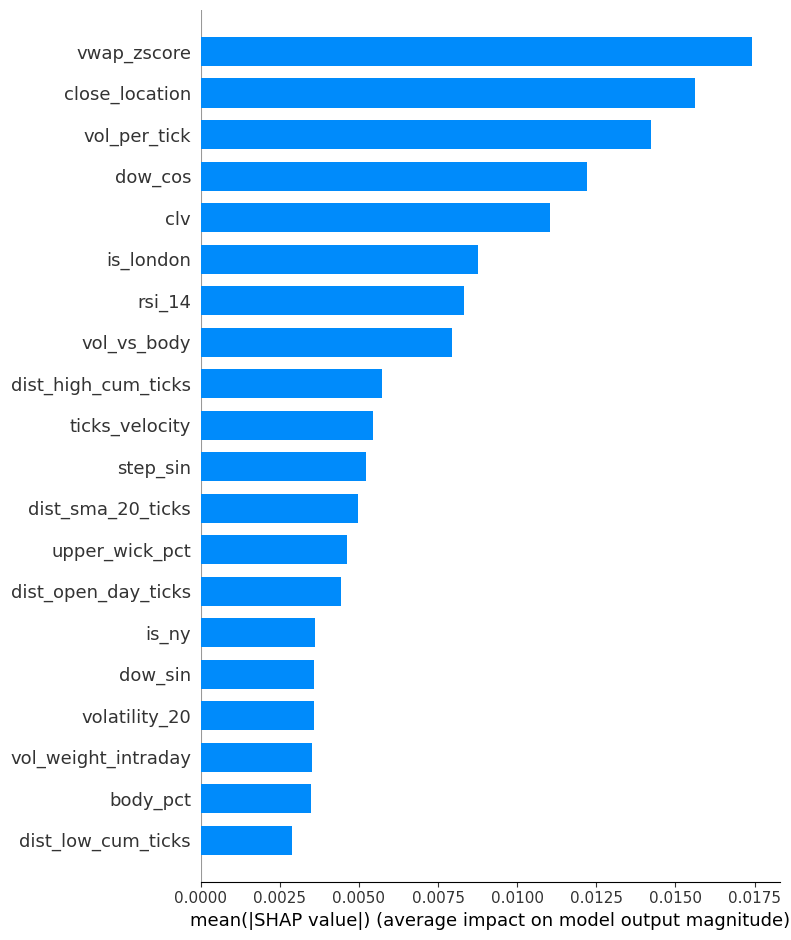

In [35]:
explain_gold_model(model, df_test_reciente, FEATURE_COLUMNS, 24, sc)

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

def sensitivity_scan(df_results, tp_range, sl_range, commission=1.0):
    """
    Prueba combinaciones de TP y SL para ver la estabilidad del Sharpe.
    """
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    
    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            pnl = []
            for _, row in df_results.iterrows():
                # Simulamos la lógica de salida
                # Si predice 1 (Compra)
                if row['pred'] == 1:
                    if row['ret_real'] >= tp:
                        pnl.append(tp - commission)
                    elif row['ret_real'] <= -sl:
                        pnl.append(-sl - commission)
                    else:
                        pnl.append(row['ret_real'] - commission)
                # Si predice 0 (Venta/Nada según tu modelo)
                # Ajustar aquí si tu modelo es binario 0/1 o -1/1
            
            if len(pnl) > 0:
                mean_pnl = np.mean(pnl)
                std_pnl = np.std(pnl) if np.std(pnl) > 0 else 1
                # Sharpe anualizado simplificado
                sharpe = (mean_pnl / std_pnl) * np.sqrt(252 * 10) # Ajustar según frecuencia
                matrix_sharpe[i, j] = sharpe

    # Visualización
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='RdYlGn')
    plt.title('Estabilidad del Sharpe: TP vs SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---
# Probamos TPs de 5 a 15 y SLs de 2 a 8
tps = np.arange(5, 16, 1)
sls = np.arange(2, 9, 1)



In [ ]:
# sensitivity_scan(result_torch_filtered, tps, sls)

KeyboardInterrupt: 

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def sensitivity_scan_optimized(df_results, tp_range, sl_range, commission=1.0):
    """
    Versión vectorizada y optimizada para el escaneo de TP/SL.
    """
    # Convertimos columnas a arrays de numpy para velocidad máxima
    # Solo filtramos donde hubo predicción de compra (pred == 1)
    df_trades = df_results[df_results['pred'] == 1]
    returns = df_trades['ret_real'].values
    
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    
    # Pre-calculamos la raíz para anualizar
    annualization_factor = np.sqrt(252 * 10) # Ajustar según tu frecuencia real

    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Lógica vectorizada:
            # np.where(condicion, valor_si_true, valor_si_false)
            
            # 1. Si retorno >= TP, ganamos TP
            # 2. Si no, si retorno <= -SL, perdemos SL
            # 3. Si no, nos quedamos con el retorno real (salida por tiempo/cierre)
            pnl_vector = np.where(returns >= tp, tp, 
                         np.where(returns <= -sl, -sl, returns))
            
            # Restamos comisión a cada trade
            pnl_final = pnl_vector - commission
            
            if len(pnl_final) > 1:
                m = np.mean(pnl_final)
                s = np.std(pnl_final)
                if s > 0:
                    matrix_sharpe[i, j] = (m / s) * annualization_factor

    # Visualización (Idéntica a la anterior)
    plt.figure(figsize=(12, 9))
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='RdYlGn', center=0)
    plt.title('Mapa de Calor de Sharpe: Estabilidad TP vs SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---
tps = np.arange(5, 16, 1)
sls = np.arange(2, 9, 1)



In [44]:
# Ajusta el tick_size según tu activo (GC=0.1, CL=0.01, 6B=0.0001, etc.)
tick_size = 0.1 

# Creamos una columna nueva en ticks
result_torch_filtered['ret_ticks'] = result_torch_filtered['ret_real'] / tick_size

In [45]:
def run_full_strategy_scan(df_results, tp_range, sl_range, commission=1.0):
    # Filtramos solo donde el modelo dio señal de entrada
    df_trades = df_results[df_results['pred'] == 1].copy()
    
    # IMPORTANTE: Usamos la columna en TICKS
    returns = df_trades['ret_ticks'].values 
    
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    matrix_mdd = np.zeros((len(sl_range), len(tp_range)))
    
    annualization = np.sqrt(252 * 10)

    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Aplicamos TP y SL vectorizado
            pnl = np.where(returns >= tp, tp, 
                  np.where(returns <= -sl, -sl, returns))
            pnl_neto = pnl - commission
            
            if len(pnl_neto) > 1:
                # 1. Cálculo de Sharpe
                m, s = np.mean(pnl_neto), np.std(pnl_neto)
                matrix_sharpe[i, j] = (m / s) * annualization if s > 0 else 0
                
                # 2. Cálculo de Max Drawdown
                cum_pnl = np.cumsum(pnl_neto)
                peak = np.maximum.accumulate(cum_pnl)
                matrix_mdd[i, j] = np.max(peak - cum_pnl)

    # --- VISUALIZACIÓN DOBLE ---
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", cmap='RdYlGn', ax=ax[0], xticklabels=tp_range, yticklabels=sl_range)
    ax[0].set_title('ESTABILIDAD DEL SHARPE (TICKS)')
    
    sns.heatmap(matrix_mdd, annot=True, fmt=".1f", cmap='Reds', ax=ax[1], xticklabels=tp_range, yticklabels=sl_range)
    ax[1].set_title('MAX DRAWDOWN (TICKS)')
    
    plt.show()

# --- EJECUCIÓN ---
# Asegúrate de haber creado 'ret_ticks' antes
# run_full_strategy_scan(df_results, np.arange(5, 16), np.arange(2, 9), commission=1.0)

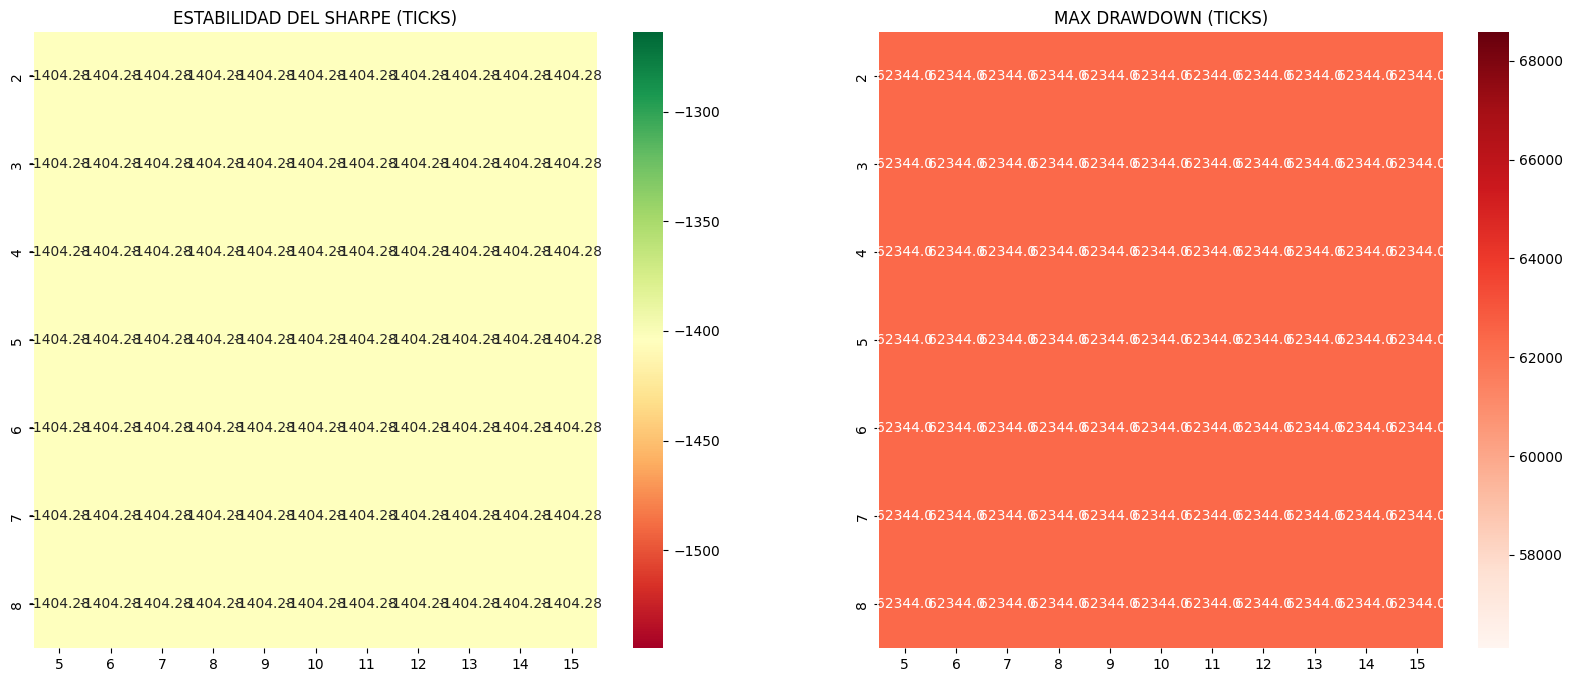

In [46]:
run_full_strategy_scan(result_torch_filtered, tps, sls)

In [47]:
def calculate_max_drawdown(pnl_array):
    """Calcula el máximo drawdown de una serie de PnL."""
    if len(pnl_array) == 0: return 0
    cumulative_pnl = np.cumsum(pnl_array)
    # Calculamos el pico máximo acumulado hasta cada punto
    peak = np.maximum.accumulate(cumulative_pnl)
    # El drawdown es la diferencia entre el pico y el valor actual
    # Si cumulative_pnl es mayor que el pico, el drawdown es 0
    drawdown = peak - cumulative_pnl
    return np.max(drawdown)

def sensitivity_scan_drawdown(df_results, tp_range, sl_range, commission=1.0):
    df_trades = df_results[df_results['pred'] == 1]
    returns = df_trades['ret_real'].values
    
    matrix_mdd = np.zeros((len(sl_range), len(tp_range)))
    
    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Lógica de TP/SL
            pnl_vector = np.where(returns >= tp, tp, 
                         np.where(returns <= -sl, -sl, returns))
            pnl_final = pnl_vector - commission
            
            # Calculamos el MDD para esta combinación
            matrix_mdd[i, j] = calculate_max_drawdown(pnl_final)

    # Visualización
    plt.figure(figsize=(12, 9))
    sns.heatmap(matrix_mdd, annot=True, fmt=".1f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='Reds')
    plt.title('Máximo Drawdown (en Ticks) por combinación TP/SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---


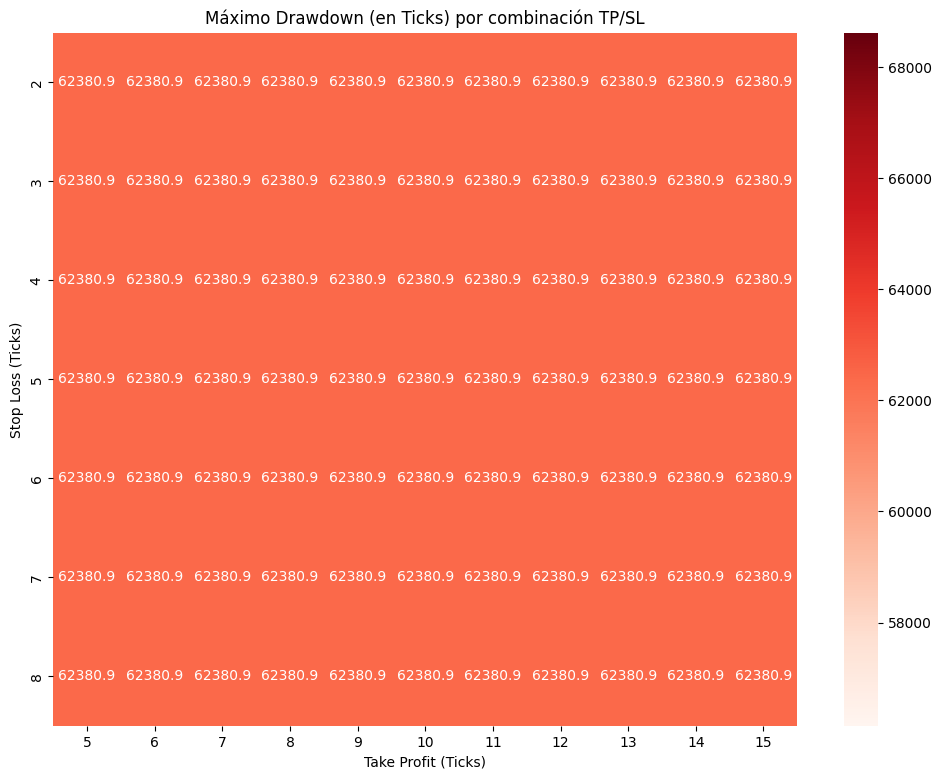

In [48]:
sensitivity_scan_drawdown(result_torch_filtered, tps, sls, commission=1.0)

In [49]:
print(f"Media de ret_ticks: {result_torch_filtered['ret_ticks'].mean()}")
print(f"Máximo de ret_ticks: {result_torch_filtered['ret_ticks'].max()}")
print(f"Mínimo de ret_ticks: {result_torch_filtered['ret_ticks'].min()}")

Media de ret_ticks: 1.2825207283023132e-05
Máximo de ret_ticks: 0.5492654790857213
Mínimo de ret_ticks: -0.5286051592192921


In [50]:
def monte_carlo_simulation(pnl_vector, iterations=1000, capital_inicial=1000):
    plt.figure(figsize=(10, 6))
    final_returns = []
    
    for _ in range(iterations):
        # Desordenamos los trades (muestreo con reemplazo)
        simulated_pnl = np.random.choice(pnl_vector, size=len(pnl_vector), replace=True)
        equity_curve = capital_inicial + np.cumsum(simulated_pnl)
        plt.plot(equity_curve, color='blue', alpha=0.01) # Curvas tenues
        final_returns.append(equity_curve[-1])
    
    plt.title(f"Simulación Monte Carlo ({iterations} caminos)")
    plt.xlabel("Número de Trades")
    plt.ylabel("Capital")
    plt.axhline(capital_inicial, color='red', linestyle='--')
    plt.show()
    
    print(f"Probabilidad de terminar en positivo: {(np.array(final_returns) > capital_inicial).mean() * 100}%")

# Uso:
# pnl_final = np.where(returns >= 8, 8, np.where(returns <= -4, -4, returns)) - 1.0
# monte_carlo_simulation(pnl_final)

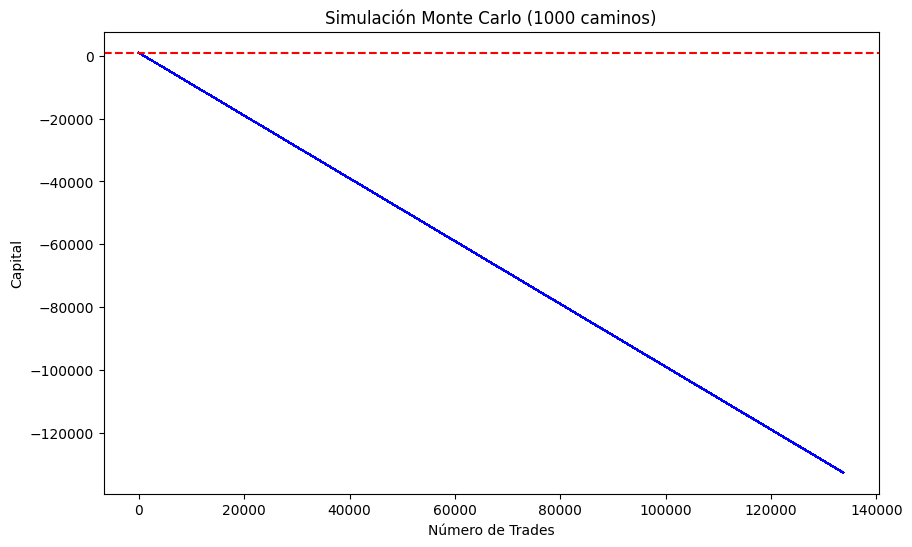

Probabilidad de terminar en positivo: 0.0%


In [51]:
pnl_final = np.where(result_torch_filtered['ret_ticks'] >= 8, 8, np.where(result_torch_filtered['ret_ticks'] <= -4, -4, result_torch_filtered['ret_ticks'])) - 1.0
monte_carlo_simulation(pnl_final)